In [26]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.covariance import LedoitWolf

CSV_PATH = "data/binance/BTCUSDT_trades_7days.parquet"

WINDOW = "5min"
N_POINTS = 64
MIN_TRADES = 50

In [27]:
def signature_length(d, depth):
    return sum(d**k for k in range(1, depth + 1))


def segment_signature(dx, depth):
    levels = [np.array([1.0])]
    tensor = np.array([1.0])

    for k in range(1, depth + 1):
        tensor = np.kron(tensor, dx)
        levels.append(tensor / math.factorial(k))

    return levels


def chen_product(A, B, depth):
    C = [np.array([1.0])]

    for n in range(1, depth + 1):
        level = np.zeros_like(A[n])

        for k in range(n + 1):
            level += np.kron(A[k], B[n-k])

        C.append(level)

    return C


def path_signature(path, depth):
    path = np.asarray(path)

    d = path.shape[1]

    sig = [np.array([1.0])]

    for k in range(1, depth + 1):
        sig.append(np.zeros(d**k))

    for dx in np.diff(path, axis=0):
        seg = segment_signature(dx, depth)
        sig = chen_product(sig, seg, depth)

    return np.concatenate(sig[1:])

In [28]:
ticks = pd.read_parquet(CSV_PATH)

ticks["timestamp"] = pd.to_datetime(
    ticks["timestamp"],
    utc=True
)

ticks["price"] = ticks["price"].astype(float)
ticks["qty"] = ticks["qty"].astype(float)

ticks = ticks.sort_values("timestamp").reset_index(drop=True)

ticks["trade_sign"] = np.where(
    ticks["is_buyer_maker"],
    -1,   # aggressive sell
    1     # aggressive buy
)

ticks["notional"] = (
    ticks["price"] *
    ticks["qty"]
)

ticks["signed_notional"] = (
    ticks["trade_sign"] *
    ticks["notional"]
)

In [29]:
def make_window(g, n_points=64):

    if len(g) < MIN_TRADES:
        return None

    g = g.sort_values("timestamp")

    # ---------------------------------
    # TIME
    # ---------------------------------

    t = (
        g["timestamp"]
        .astype("int64")
        .to_numpy(float)
    )

    t = (t - t[0]) / (t[-1] - t[0])

    # ---------------------------------
    # LOG PRICE
    # ---------------------------------

    log_price = np.log(
        g["price"].to_numpy(float)
    )

    # Start every window from zero
    log_price = 100 * (
        log_price - log_price[0]
    )

    # ---------------------------------
    # CUMULATIVE ORDER IMBALANCE
    # ---------------------------------

    signed = g["signed_notional"].to_numpy(float)
    absolute = g["notional"].to_numpy(float)

    imbalance = (
        np.cumsum(signed) /
        np.sum(absolute)
    )

    # ---------------------------------
    # RESAMPLE TO SAME NUMBER OF POINTS
    # ---------------------------------

    old_x = np.linspace(0, 1, len(g))
    new_x = np.linspace(0, 1, n_points)

    t = np.interp(new_x, old_x, t)
    log_price = np.interp(new_x, old_x, log_price)
    imbalance = np.interp(new_x, old_x, imbalance)

    path_price = np.column_stack([
        t,
        log_price
    ])

    path_price_imbalance = np.column_stack([
        t,
        log_price,
        imbalance
    ])

    return path_price, path_price_imbalance

price_paths = []
imbalance_paths = []
window_times = []

grouped = ticks.groupby(
    pd.Grouper(
        key="timestamp",
        freq=WINDOW
    )
)

for start, g in grouped:

    result = make_window(g)

    if result is None:
        continue

    p_price, p_imbalance = result

    price_paths.append(p_price)
    imbalance_paths.append(p_imbalance)
    window_times.append(start)


print("Number of windows:", len(price_paths))
print("Price path shape:", price_paths[0].shape)
print("Price + imbalance shape:", imbalance_paths[0].shape)

Number of windows: 2016
Price path shape: (64, 2)
Price + imbalance shape: (64, 3)


In [30]:
def build_signatures(paths, depth):

    return np.vstack([
        path_signature(path, depth)
        for path in paths
    ])

price_signatures = {}

for depth in [1, 2, 3, 4]:

    X = build_signatures(
        price_paths,
        depth
    )

    price_signatures[depth] = X

    print(
        f"Depth {depth}: "
        f"{X.shape[1]} features"
    )

Depth 1: 2 features
Depth 2: 6 features
Depth 3: 14 features
Depth 4: 30 features


In [32]:
np.random.seed(42)

N_PATHS_PER_CLASS = 200
N_POINTS = 64
def generate_path(path_type, n_points=64, noise=0.08):

    t = np.linspace(0, 1, n_points)

    if path_type == "uptrend":
        price = 2 * t

    elif path_type == "downtrend":
        price = -2 * t

    elif path_type == "crash_recovery":
        price = np.where(
            t < 0.5,
            -4 * t,
            -2 + 4 * (t - 0.5)
        )

    elif path_type == "spike_reversal":
        price = np.where(
            t < 0.5,
            4 * t,
            2 - 4 * (t - 0.5)
        )

    elif path_type == "oscillating":
        price = np.sin(4 * np.pi * t)

    elif path_type == "flat":
        price = np.zeros_like(t)

    else:
        raise ValueError("Unknown path type")

    # Add random noise
    price += np.random.normal(
        0,
        noise,
        size=n_points
    )

    # Use time + price
    path = np.column_stack([
        t,
        price
    ])

    return path

path_types = [
    "uptrend",
    "downtrend",
    "crash_recovery",
    "spike_reversal",
    "oscillating",
    "flat"
]

paths = []
labels = []

for path_type in path_types:

    for _ in range(N_PATHS_PER_CLASS):

        path = generate_path(
            path_type,
            n_points=N_POINTS
        )

        paths.append(path)
        labels.append(path_type)

labels = np.array(labels)

print(len(paths))
print(labels.shape)

1200
(1200,)


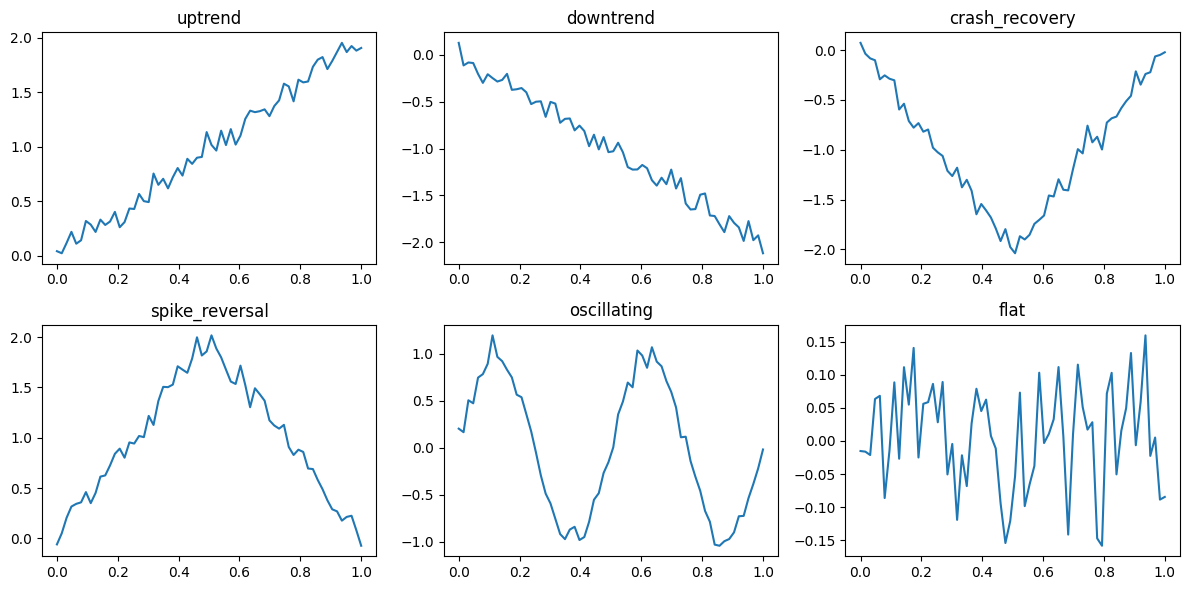

In [33]:
fig, axes = plt.subplots(
    2,
    3,
    figsize=(12, 6)
)

axes = axes.flatten()

for ax, path_type in zip(
    axes,
    path_types
):

    idx = np.where(
        labels == path_type
    )[0][0]

    path = paths[idx]

    ax.plot(
        path[:, 0],
        path[:, 1]
    )

    ax.set_title(path_type)

plt.tight_layout()
plt.show()

In [34]:
import math

def signature_length(d, depth):
    return sum(d**k for k in range(1, depth + 1))


def segment_signature(dx, depth):

    levels = [np.array([1.0])]

    tensor = np.array([1.0])

    for k in range(1, depth + 1):

        tensor = np.kron(
            tensor,
            dx
        )

        levels.append(
            tensor / math.factorial(k)
        )

    return levels


def chen_product(A, B, depth):

    C = [np.array([1.0])]

    for n in range(1, depth + 1):

        level = np.zeros_like(
            A[n]
        )

        for k in range(n + 1):

            level += np.kron(
                A[k],
                B[n-k]
            )

        C.append(level)

    return C


def path_signature(path, depth):

    path = np.asarray(path)

    d = path.shape[1]

    sig = [np.array([1.0])]

    for k in range(1, depth + 1):
        sig.append(
            np.zeros(d**k)
        )

    for dx in np.diff(
        path,
        axis=0
    ):

        segment = segment_signature(
            dx,
            depth
        )

        sig = chen_product(
            sig,
            segment,
            depth
        )

    return np.concatenate(
        sig[1:]
    )

In [35]:
signature_features = {}

for depth in [1, 2, 3, 4]:

    X = np.vstack([
        path_signature(
            path,
            depth
        )
        for path in paths
    ])

    signature_features[depth] = X

    print(
        f"Depth {depth}: "
        f"{X.shape}"
    )

Depth 1: (1200, 2)
Depth 2: (1200, 6)
Depth 3: (1200, 14)
Depth 4: (1200, 30)


In [36]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_score
)
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

results = []

for depth, X in signature_features.items():

    model = Pipeline([
        (
            "scaler",
            StandardScaler()
        ),
        (
            "model",
            LogisticRegression(
                max_iter=3000
            )
        )
    ])

    scores = cross_val_score(
        model,
        X,
        labels,
        cv=cv,
        scoring="accuracy"
    )

    results.append({
        "depth": depth,
        "n_features": X.shape[1],
        "accuracy_mean": scores.mean(),
        "accuracy_std": scores.std()
    })

results = pd.DataFrame(results)

print(results)

   depth  n_features  accuracy_mean  accuracy_std
0      1           2       0.498333      0.018930
1      2           6       0.825833      0.008898
2      3          14       1.000000      0.000000
3      4          30       1.000000      0.000000


we choose depth 3

In [37]:
DEPTH = 3

X_sig_price = build_signatures(
    price_paths,
    DEPTH
)

X_sig_imbalance = build_signatures(
    imbalance_paths,
    DEPTH
)

print(X_sig_price.shape)
print(X_sig_imbalance.shape)

(2016, 14)
(2016, 39)


In [38]:
def summary_features(g):

    price = g["price"].to_numpy(float)

    log_price = np.log(price)
    returns = np.diff(log_price)

    return [
        100 * (log_price[-1] - log_price[0]),
        100 * np.sqrt(np.sum(returns**2)),
        100 * (log_price.max() - log_price.min()),
        g["signed_notional"].sum() /
        g["notional"].sum()
    ]

In [40]:
summaries = []

for start, g in grouped:

    if len(g) < MIN_TRADES:
        continue

    summaries.append(
        summary_features(g)
    )

X_summary = np.array(summaries)

In [39]:
def mahalanobis_scores(X):

    X = StandardScaler().fit_transform(X)

    model = LedoitWolf().fit(X)

    center = X.mean(axis=0)
    precision = model.precision_

    diff = X - center

    distance_sq = np.einsum(
        "ij,jk,ik->i",
        diff,
        precision,
        diff
    )

    return np.sqrt(distance_sq)

In [41]:
score_summary = mahalanobis_scores(
    X_summary
)

score_sig_price = mahalanobis_scores(
    X_sig_price
)

score_sig_imbalance = mahalanobis_scores(
    X_sig_imbalance
)

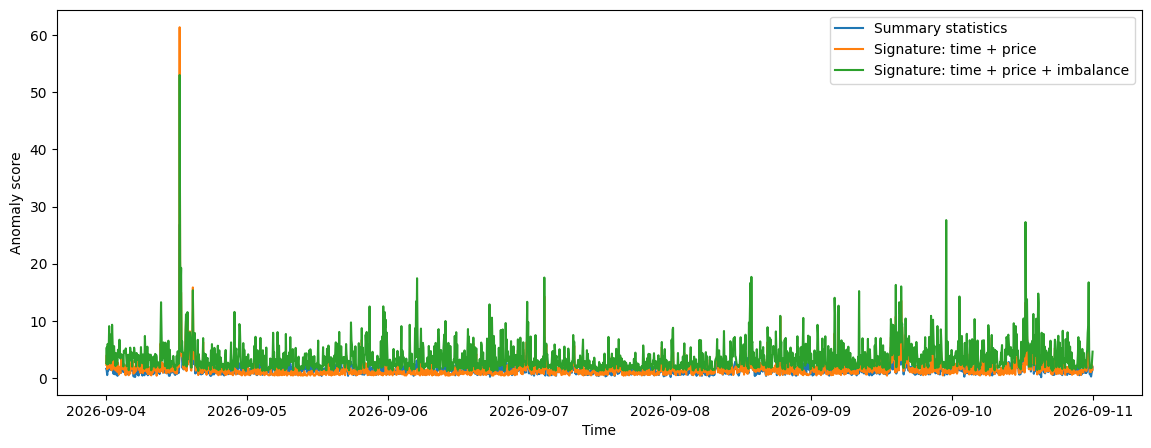

In [42]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    window_times,
    score_summary,
    label="Summary statistics"
)

ax.plot(
    window_times,
    score_sig_price,
    label="Signature: time + price"
)

ax.plot(
    window_times,
    score_sig_imbalance,
    label="Signature: time + price + imbalance"
)

ax.set_xlabel("Time")
ax.set_ylabel("Anomaly score")
ax.legend()

plt.show()

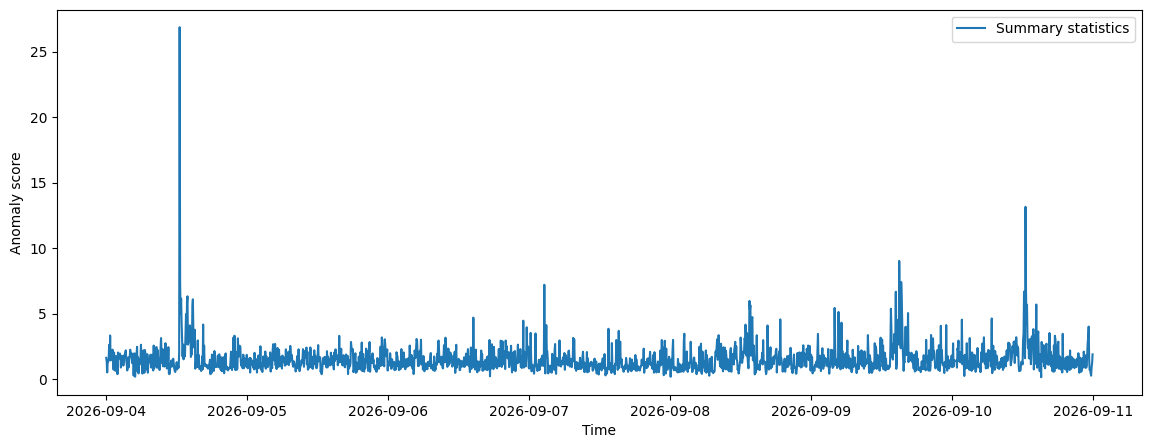

In [46]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(
    window_times,
    score_summary,
    label="Summary statistics"
)
ax.set_xlabel("Time")
ax.set_ylabel("Anomaly score")
ax.legend()

plt.show()

investigating anamolous price paths

In [51]:
results = pd.DataFrame({
    "time": window_times,
    "summary_score": score_summary,
    "sig_price_score": score_sig_price,
    "sig_imbalance_score": score_sig_imbalance
})

In [52]:
results["summary_pct"] = (
    results["summary_score"]
    .rank(pct=True)
)

results["sig_price_pct"] = (
    results["sig_price_score"]
    .rank(pct=True)
)

results["sig_imbalance_pct"] = (
    results["sig_imbalance_score"]
    .rank(pct=True)
)

In [53]:
results["summary_pct"] = (
    results["summary_score"]
    .rank(pct=True)
)

results["sig_price_pct"] = (
    results["sig_price_score"]
    .rank(pct=True)
)

results["sig_imbalance_pct"] = (
    results["sig_imbalance_score"]
    .rank(pct=True)
)

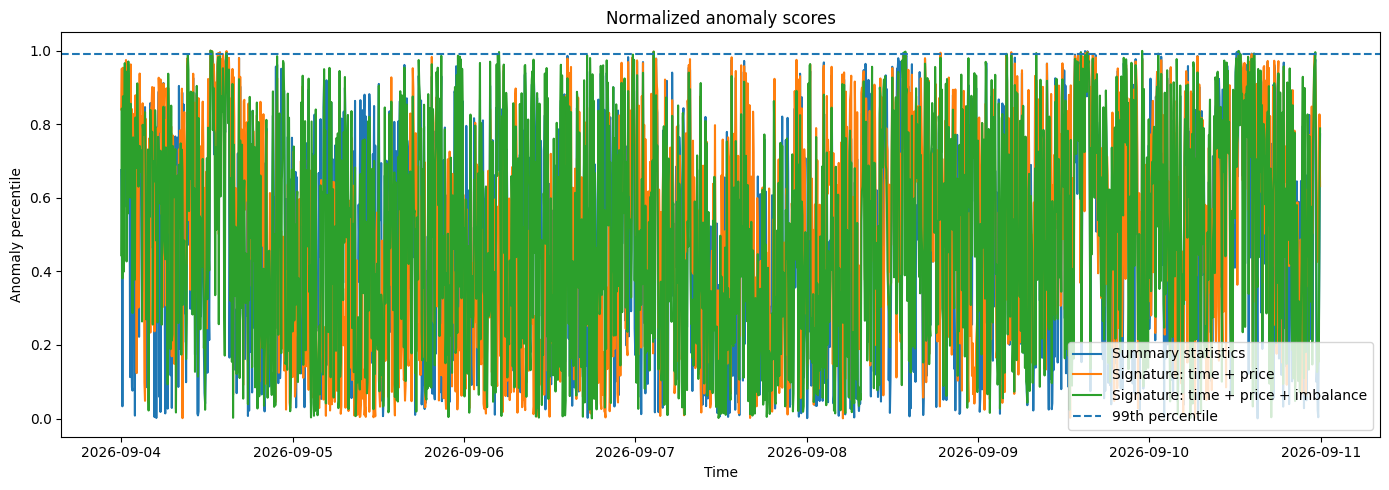

In [54]:
plt.figure(figsize=(14, 5))

plt.plot(
    results["time"],
    results["summary_pct"],
    label="Summary statistics"
)

plt.plot(
    results["time"],
    results["sig_price_pct"],
    label="Signature: time + price"
)

plt.plot(
    results["time"],
    results["sig_imbalance_pct"],
    label="Signature: time + price + imbalance"
)

plt.axhline(
    0.99,
    linestyle="--",
    label="99th percentile"
)

plt.xlabel("Time")
plt.ylabel("Anomaly percentile")
plt.title("Normalized anomaly scores")

plt.legend()
plt.tight_layout()
plt.show()

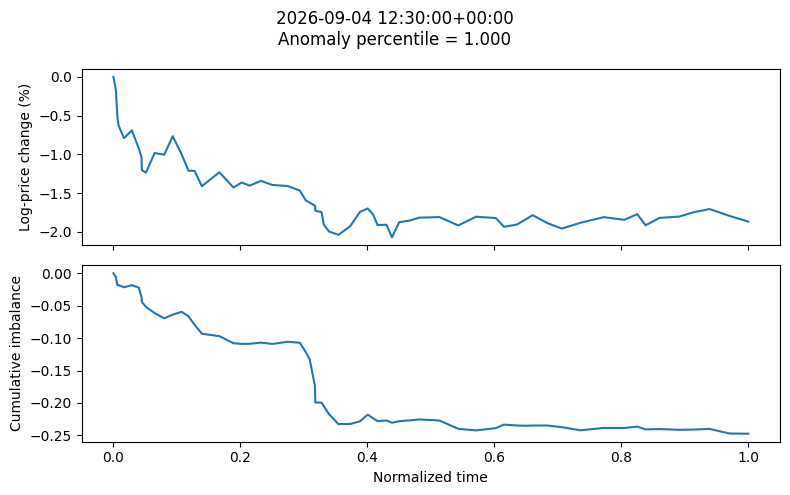

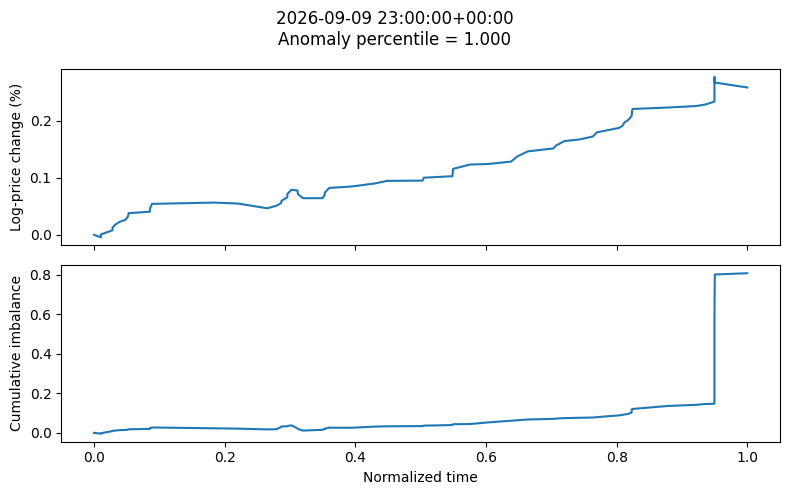

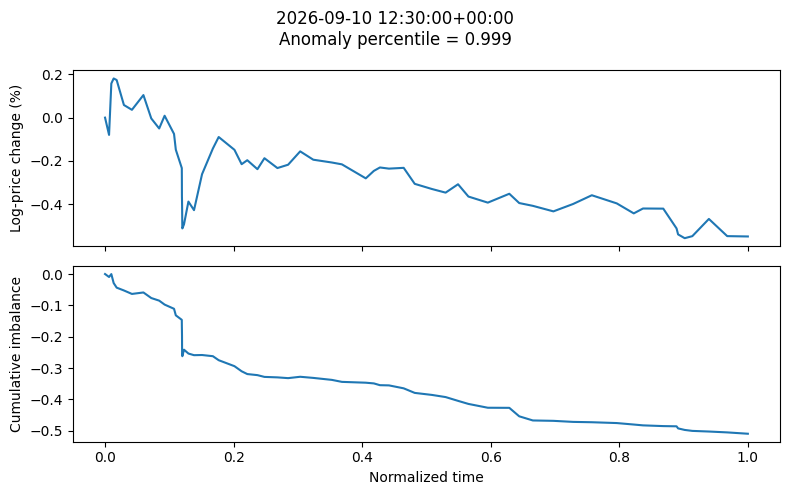

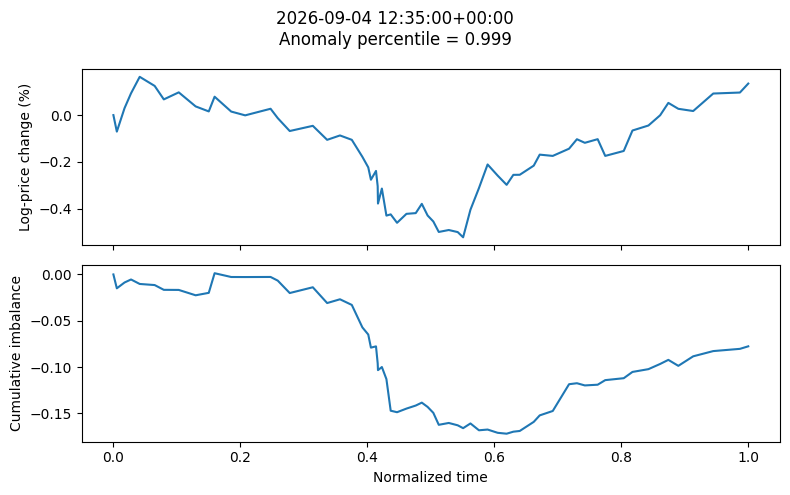

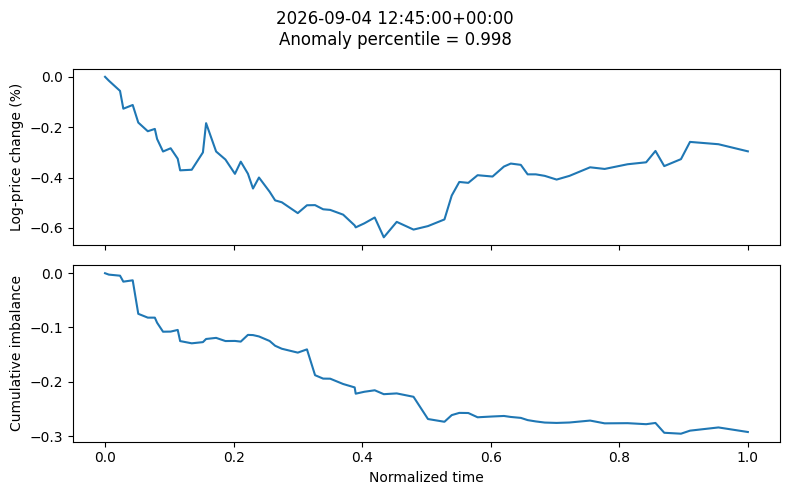

In [57]:
top_indices = (
    results["sig_imbalance_pct"]
    .nlargest(5)
    .index
)

for idx in top_indices:

    path = imbalance_paths[idx]

    fig, axes = plt.subplots(
        2,
        1,
        figsize=(8, 5),
        sharex=True
    )

    # Price
    axes[0].plot(
        path[:, 0],
        path[:, 1]
    )

    axes[0].set_ylabel(
        "Log-price change (%)"
    )

    # Imbalance
    axes[1].plot(
        path[:, 0],
        path[:, 2]
    )

    axes[1].set_ylabel(
        "Cumulative imbalance"
    )

    axes[1].set_xlabel(
        "Normalized time"
    )

    fig.suptitle(
        f"{results.loc[idx, 'time']}\n"
        f"Anomaly percentile = "
        f"{results.loc[idx, 'sig_imbalance_pct']:.3f}"
    )

    plt.tight_layout()
    plt.show()

In [60]:
# Stack all paths
price_array = np.stack(price_paths)
imbalance_array = np.stack(imbalance_paths)

# Average price path across all windows
avg_price_path = price_array[:, :, 1].mean(axis=0)

# Average imbalance path across all windows
avg_imbalance_path = imbalance_array[:, :, 2].mean(axis=0)

# Common normalized time axis
time_axis = price_array[0, :, 0]

In [63]:
price_q25 = np.percentile(
    price_array[:, :, 1],
    25,
    axis=0
)

price_q75 = np.percentile(
    price_array[:, :, 1],
    75,
    axis=0
)

imbalance_q25 = np.percentile(
    imbalance_array[:, :, 2],
    25,
    axis=0
)

imbalance_q75 = np.percentile(
    imbalance_array[:, :, 2],
    75,
    axis=0
)

In [61]:
results["sig_vs_summary"] = (
    results["sig_imbalance_pct"]
    - results["summary_pct"]
)

interesting = (
    results
    .sort_values(
        "sig_vs_summary",
        ascending=False
    )
    .head(5)
)

interesting

,time,summary_score,sig_price_score,sig_imbalance_score,summary_pct,sig_price_pct,sig_imbalance_pct,sig_vs_summary
130,2026-09-04 10:50:00+00:00,0.452417,2.593287,4.938372,0.018849,0.871032,0.816964,0.798115
387,2026-09-05 08:15:00+00:00,0.591992,1.931056,5.281699,0.055556,0.763889,0.835813,0.780258
673,2026-09-06 08:05:00+00:00,0.735664,0.908244,6.152110,0.115575,0.328373,0.884425,0.768849
647,2026-09-06 05:55:00+00:00,0.738830,1.714216,6.156654,0.118056,0.702877,0.885417,0.767361
305,2026-09-05 01:25:00+00:00,0.818873,3.033438,7.220659,0.175595,0.903274,0.932044,0.756448


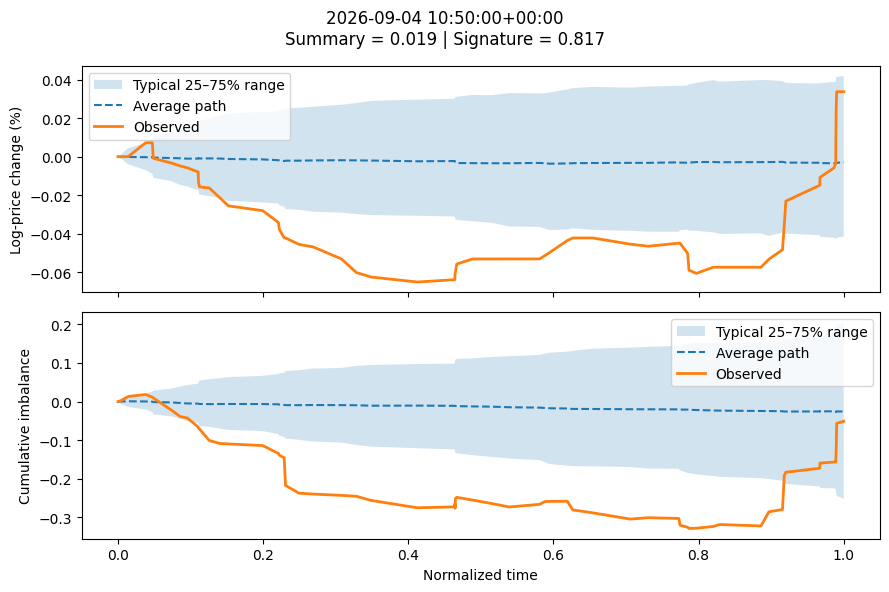

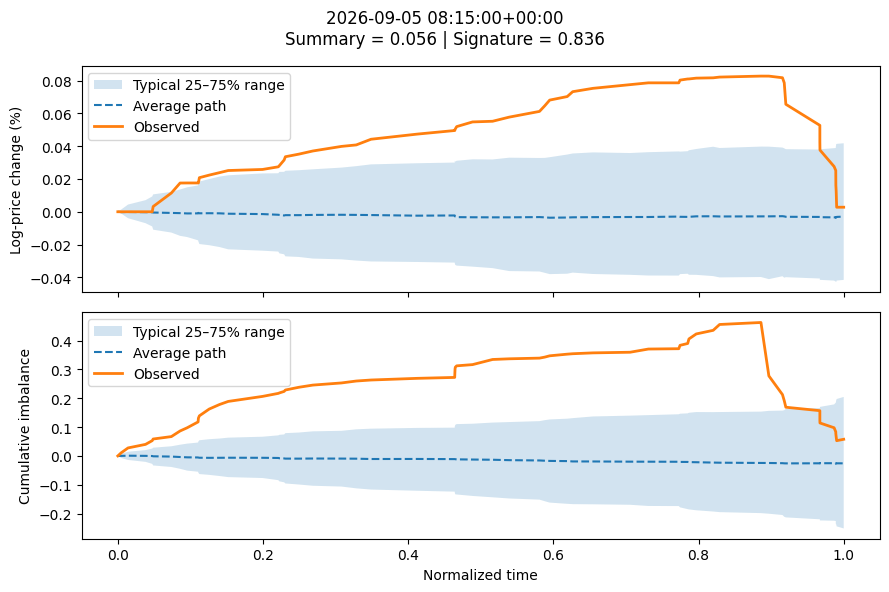

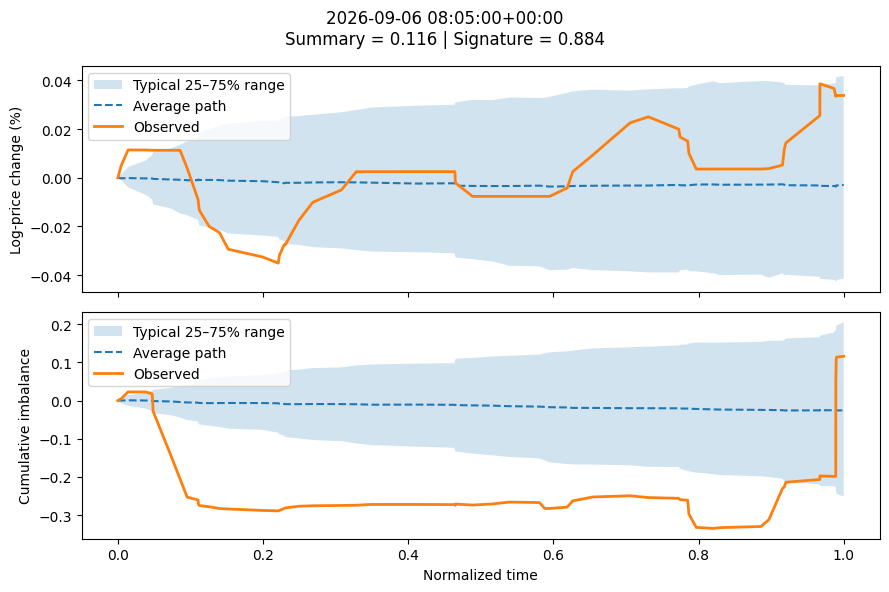

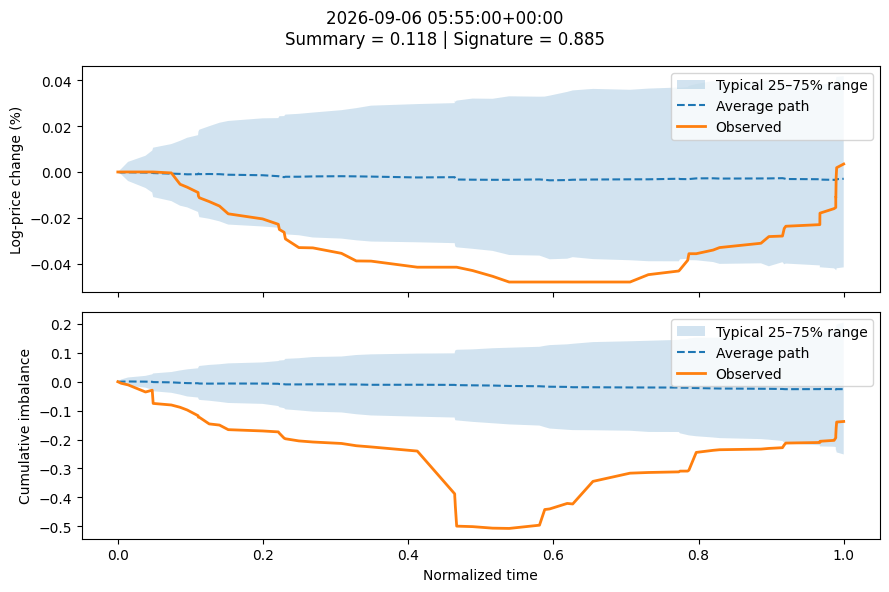

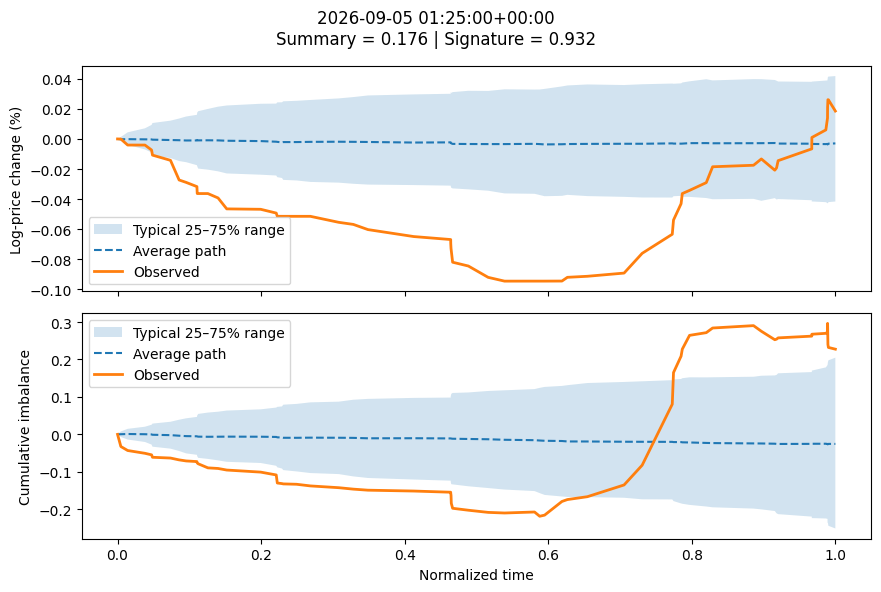

In [64]:
for idx in interesting.index:

    path = imbalance_paths[idx]

    observed_price = path[:, 1]
    observed_imbalance = path[:, 2]

    fig, axes = plt.subplots(
        2,
        1,
        figsize=(9, 6),
        sharex=True
    )

    # =====================================
    # PRICE
    # =====================================

    axes[0].fill_between(
        time_axis,
        price_q25,
        price_q75,
        alpha=0.2,
        label="Typical 25–75% range"
    )

    axes[0].plot(
        time_axis,
        avg_price_path,
        linestyle="--",
        label="Average path"
    )

    axes[0].plot(
        time_axis,
        observed_price,
        linewidth=2,
        label="Observed"
    )

    axes[0].set_ylabel(
        "Log-price change (%)"
    )

    axes[0].legend()

    # =====================================
    # IMBALANCE
    # =====================================

    axes[1].fill_between(
        time_axis,
        imbalance_q25,
        imbalance_q75,
        alpha=0.2,
        label="Typical 25–75% range"
    )

    axes[1].plot(
        time_axis,
        avg_imbalance_path,
        linestyle="--",
        label="Average path"
    )

    axes[1].plot(
        time_axis,
        observed_imbalance,
        linewidth=2,
        label="Observed"
    )

    axes[1].set_ylabel(
        "Cumulative imbalance"
    )

    axes[1].set_xlabel(
        "Normalized time"
    )

    axes[1].legend()

    fig.suptitle(
        f"{results.loc[idx, 'time']}\n"
        f"Summary = "
        f"{results.loc[idx, 'summary_pct']:.3f} | "
        f"Signature = "
        f"{results.loc[idx, 'sig_imbalance_pct']:.3f}"
    )

    plt.tight_layout()
    plt.show()

timestamp
2026-09-04 00:00:00+00:00    0.000000
2026-09-04 00:05:00+00:00    0.105386
2026-09-04 00:10:00+00:00    0.176617
2026-09-04 00:15:00+00:00    0.105747
2026-09-04 00:20:00+00:00    0.123533
Freq: 5T, Name: price, dtype: float64
Number of forecasting observations: 1938
HAR shape: (1938, 3)
Target shape: (1938,)

Price signature shape: (1938, 42)
Price + imbalance signature shape: (1938, 117)

Train observations: 1350
Test observations: 582

Last training time: 2026-09-08 22:30:00+00:00
First test time: 2026-09-08 23:05:00+00:00

MODEL RESULTS
                          model     RMSE      MAE       R2
0             HAR: 5m + 1h + 6h  0.10036  0.06262  0.33866
1                 Last 5-min RV  0.11329  0.06966  0.15726
2              Signature: price  0.12815  0.07922 -0.07847
3               HAR + signature  0.12975  0.08735 -0.10556
4  Signature: price + imbalance  0.15953  0.10572 -0.67113


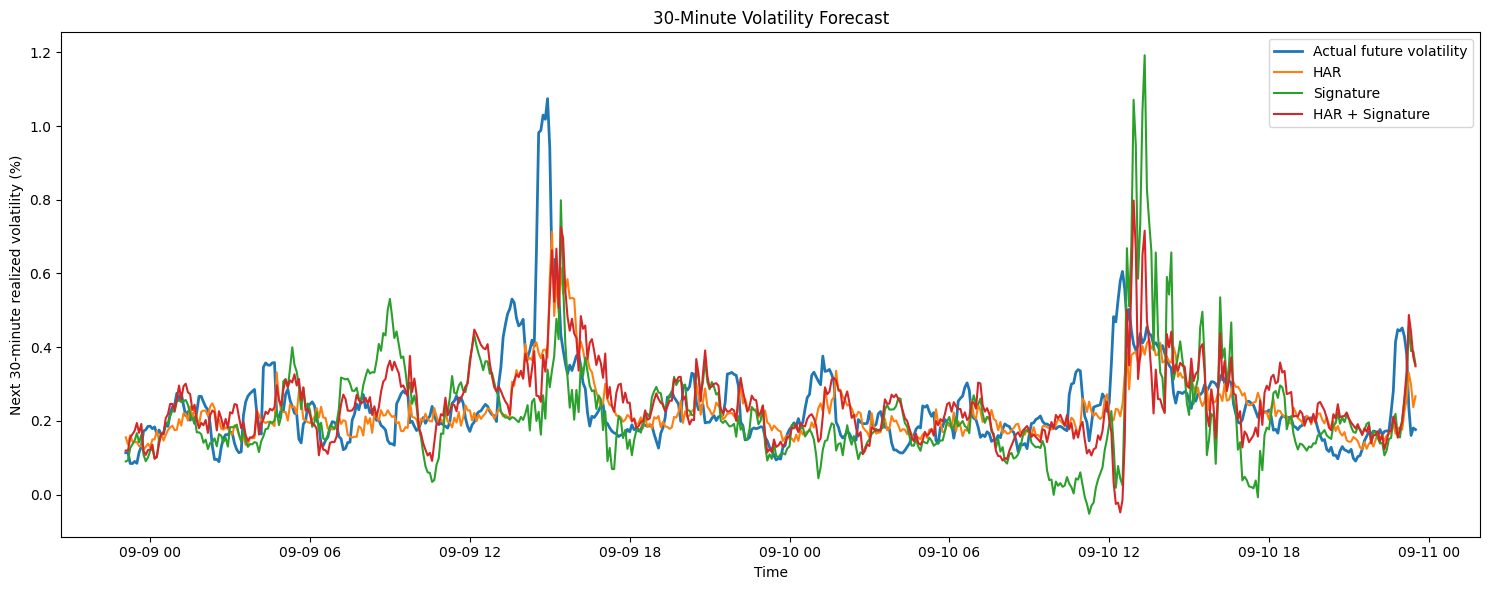

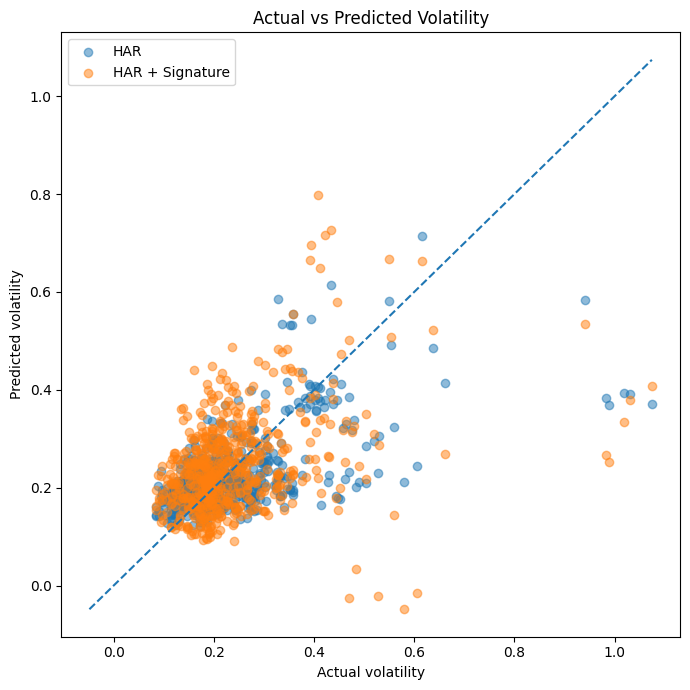

In [66]:
# ============================================================
# LEAD-LAG TRANSFORMATION
# ============================================================

def lead_lag_path(price):

    price = np.asarray(price)

    path = [
        [price[0], price[0]]
    ]

    for i in range(1, len(price)):

        # Lead coordinate moves
        path.append([
            price[i],
            price[i - 1]
        ])

        # Lag coordinate follows
        path.append([
            price[i],
            price[i]
        ])

    return np.asarray(path)

# ============================================================
# CREATE LEAD-LAG PATHS
# ============================================================

lead_lag_paths = {}

for lookback in LOOKBACKS:

    lead_lag_paths[lookback] = []

    for path in price_paths[lookback]:

        # Original:
        # path[:, 0] = time
        # path[:, 1] = log-price

        price = path[:, 1]

        ll_path = lead_lag_path(
            price
        )

        lead_lag_paths[
            lookback
        ].append(
            ll_path
        )

# ============================================================
# LEAD-LAG SIGNATURES
# ============================================================

LL_DEPTH = 2

signature_blocks = []

for lookback in LOOKBACKS:

    X = build_signatures(
        lead_lag_paths[lookback],
        LL_DEPTH
    )

    print(
        lookback,
        X.shape
    )

    signature_blocks.append(
        X
    )


X_sig_leadlag = np.hstack(
    signature_blocks
)

print(
    "Final lead-lag signature shape:",
    X_sig_leadlag.shape
)

1h (1938, 6)
3h (1938, 6)
6h (1938, 6)
Final lead-lag signature shape: (1938, 18)


In [67]:
# ============================================================
# 1. FIT HAR
# ============================================================

har_model = LinearRegression()

har_model.fit(
    X_har[train_idx],
    y[train_idx]
)


# ============================================================
# 2. HAR TRAINING PREDICTIONS
# ============================================================

har_train_pred = har_model.predict(
    X_har[train_idx]
)


# ============================================================
# 3. WHAT HAR FAILED TO EXPLAIN
# ============================================================

har_residual_train = (
    y[train_idx]
    - har_train_pred
)


# ============================================================
# 4. TRY TO PREDICT HAR'S ERROR
#    USING LEAD-LAG SIGNATURES
# ============================================================

residual_model = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "ridge",
        RidgeCV(
            alphas=np.logspace(
                -4,
                5,
                30
            )
        )
    )
])


residual_model.fit(
    X_sig_leadlag[train_idx],
    har_residual_train
)


# ============================================================
# 5. TEST SET
# ============================================================

har_test_pred = har_model.predict(
    X_har[test_idx]
)

signature_correction = residual_model.predict(
    X_sig_leadlag[test_idx]
)


final_prediction = (
    har_test_pred
    + signature_correction
)


# ============================================================
# EVALUATE
# ============================================================

rmse = np.sqrt(
    mean_squared_error(
        y[test_idx],
        final_prediction
    )
)

mae = mean_absolute_error(
    y[test_idx],
    final_prediction
)

r2 = r2_score(
    y[test_idx],
    final_prediction
)


print(
    "HAR + lead-lag residual model"
)

print(
    "RMSE:", rmse
)

print(
    "MAE:", mae
)

print(
    "R2:", r2
)

HAR + lead-lag residual model
RMSE: 0.10370400322914991
MAE: 0.06644855228628616
R2: 0.29380196024824967


# Anomaly Detection

In [68]:
# ============================================================
# NEXT 5-MINUTE REGIME PREDICTION
#
# Predict:
#   Is the NEXT 5-minute window normal or abnormal?
#
# Compare feature representations:
#
# 1. Price signature
# 2. Price + imbalance signature
# 3. Price lead-lag signature
# 4. Price + imbalance lead-lag signature
#
# Models:
#
# 1. One-Class SVM
# 2. Isolation Forest
# ============================================================


# %%
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.svm import OneClassSVM
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)


# ============================================================
# SETTINGS
# ============================================================

WINDOW = "5min"

# Level 2 is enough to capture lead-lag area
SIG_DEPTH = 2

# First 70% training, last 30% testing
TRAIN_FRAC = 0.70

# Definition of abnormal
N_STD = 2.0


# ============================================================
# ASSUMES YOU ALREADY HAVE
#
# ticks
# make_window()
# path_signature()
# build_signatures()
#
# from your existing notebook
# ============================================================


# ============================================================
# 1. BUILD EACH 5-MINUTE WINDOW
# ============================================================

window_times = []

price_paths = []
imbalance_paths = []

window_returns = []


grouped = ticks.groupby(
    pd.Grouper(
        key="timestamp",
        freq=WINDOW
    )
)


for start, g in grouped:

    # Skip empty / small windows
    if len(g) < MIN_TRADES:
        continue

    path_result = make_window(
        g
    )

    if path_result is None:
        continue

    price_path, imbalance_path = path_result

    # --------------------------------------------
    # 5-minute return
    #
    # Used ONLY to define normal/abnormal label
    # --------------------------------------------

    prices = g["price"].to_numpy(float)

    five_min_return = (
        100
        * (
            np.log(prices[-1])
            - np.log(prices[0])
        )
    )

    window_times.append(
        start
    )

    price_paths.append(
        price_path
    )

    imbalance_paths.append(
        imbalance_path
    )

    window_returns.append(
        five_min_return
    )


window_times = pd.DatetimeIndex(
    window_times
)

window_returns = np.asarray(
    window_returns
)


print(
    "Number of 5-minute windows:",
    len(window_times)
)

Number of 5-minute windows: 2016


In [69]:
# ============================================================
# 2. CHRONOLOGICAL SPLIT
# ============================================================

n_windows = len(
    window_times
)

split_window = int(
    TRAIN_FRAC * n_windows
)


train_returns = window_returns[
    :split_window
]


# ============================================================
# NORMAL REGIME DISTRIBUTION
# ============================================================

return_mean = (
    train_returns.mean()
)

return_std = (
    train_returns.std(
        ddof=1
    )
)


lower_threshold = (
    return_mean
    - N_STD * return_std
)

upper_threshold = (
    return_mean
    + N_STD * return_std
)


print(
    "Mean 5-min return:",
    return_mean
)

print(
    "Std 5-min return:",
    return_std
)

print(
    "Normal range:",
    lower_threshold,
    "to",
    upper_threshold
)

Mean 5-min return: -0.0024321545904400035
Std 5-min return: 0.09252655134434232
Normal range: -0.18748525727912463 to 0.18262094809824464


In [70]:
# ============================================================
# 3. REGIME LABELS
#
# 0 = normal
# 1 = abnormal
# ============================================================

labels = (
    (
        window_returns
        < lower_threshold
    )
    |
    (
        window_returns
        > upper_threshold
    )
).astype(int)


print(
    "\nTotal abnormal windows:",
    labels.sum()
)

print(
    "Abnormal percentage:",
    round(
        100 * labels.mean(),
        2
    ),
    "%"
)


Total abnormal windows: 93
Abnormal percentage: 4.61 %


In [71]:
# ============================================================
# 4. LEAD-LAG TRANSFORMATION
# ============================================================

def lead_lag_path(
    path,
    value_columns
):

    """
    path:
        original path

    value_columns:
        columns to lead-lag

    Example:

    price path:
        columns [time, price]

    value_columns = [1]

    Result:
        [time,
         price_lead,
         price_lag]


    price + imbalance:

    value_columns = [1, 2]

    Result:
        [time,
         price_lead,
         price_lag,
         imbalance_lead,
         imbalance_lag]
    """

    time = path[:, 0]

    values = path[
        :,
        value_columns
    ]

    new_path = []

    # First point

    first = [
        time[0]
    ]

    for j in range(
        values.shape[1]
    ):

        first.extend([
            values[0, j],
            values[0, j]
        ])

    new_path.append(
        first
    )


    # Build lead-lag steps

    for i in range(
        1,
        len(path)
    ):

        # -----------------------------------------
        # LEAD MOVES
        # -----------------------------------------

        lead_point = [
            time[i]
        ]

        for j in range(
            values.shape[1]
        ):

            lead_point.extend([
                values[i, j],
                values[i - 1, j]
            ])

        new_path.append(
            lead_point
        )


        # -----------------------------------------
        # LAG CATCHES UP
        # -----------------------------------------

        lag_point = [
            time[i]
        ]

        for j in range(
            values.shape[1]
        ):

            lag_point.extend([
                values[i, j],
                values[i, j]
            ])

        new_path.append(
            lag_point
        )


    return np.asarray(
        new_path
    )

In [72]:
# ============================================================
# 5. CREATE LEAD-LAG PATHS
# ============================================================

price_leadlag_paths = []

imbalance_leadlag_paths = []


for price_path, imbalance_path in zip(
    price_paths,
    imbalance_paths
):

    # --------------------------------------------
    # PRICE LEAD-LAG
    #
    # Original:
    # [time, price]
    #
    # Result:
    # [time, price_lead, price_lag]
    # --------------------------------------------

    price_ll = lead_lag_path(
        price_path,
        value_columns=[1]
    )

    price_leadlag_paths.append(
        price_ll
    )


    # --------------------------------------------
    # PRICE + IMBALANCE LEAD-LAG
    #
    # Original:
    # [time, price, imbalance]
    #
    # Result:
    # [time,
    #  price_lead,
    #  price_lag,
    #  imbalance_lead,
    #  imbalance_lag]
    # --------------------------------------------

    imbalance_ll = lead_lag_path(
        imbalance_path,
        value_columns=[1, 2]
    )

    imbalance_leadlag_paths.append(
        imbalance_ll
    )

In [73]:
# ============================================================
# 6. SIGNATURE FEATURES
# ============================================================

X_price = build_signatures(
    price_paths,
    SIG_DEPTH
)


X_price_imbalance = build_signatures(
    imbalance_paths,
    SIG_DEPTH
)


X_price_leadlag = build_signatures(
    price_leadlag_paths,
    SIG_DEPTH
)


X_price_imbalance_leadlag = build_signatures(
    imbalance_leadlag_paths,
    SIG_DEPTH
)


print(
    "Price:",
    X_price.shape
)

print(
    "Price + imbalance:",
    X_price_imbalance.shape
)

print(
    "Price lead-lag:",
    X_price_leadlag.shape
)

print(
    "Price + imbalance lead-lag:",
    X_price_imbalance_leadlag.shape
)

Price: (2016, 6)
Price + imbalance: (2016, 12)
Price lead-lag: (2016, 12)
Price + imbalance lead-lag: (2016, 30)


In [74]:
# ============================================================
# 7. CURRENT WINDOW -> NEXT WINDOW
# ============================================================

feature_sets = {

    "Price":
        X_price,

    "Price + Imbalance":
        X_price_imbalance,

    "Price Lead-Lag":
        X_price_leadlag,

    "Price + Imbalance Lead-Lag":
        X_price_imbalance_leadlag
}


# Is the next window exactly 5 minutes later?

time_difference = (
    window_times[1:]
    - window_times[:-1]
)

consecutive = (
    time_difference
    == pd.Timedelta("5min")
)


# Current-window indices
current_indices = np.arange(
    len(window_times) - 1
)

# Keep only consecutive windows
current_indices = current_indices[
    consecutive
]


# Target is NEXT window
target_indices = (
    current_indices
    + 1
)


# --------------------------------------------
# Target variable
#
# 0 = next window normal
# 1 = next window abnormal
# --------------------------------------------

y_next = labels[
    target_indices
]


# --------------------------------------------
# Current regime
#
# Needed because one-class models are trained
# only on NORMAL CURRENT windows.
# --------------------------------------------

y_current = labels[
    current_indices
]


prediction_times = window_times[
    target_indices
]

In [75]:
# ============================================================
# 8. TRAIN / TEST PAIRS
# ============================================================

split_time = window_times[
    split_window
]


train_mask = (
    prediction_times
    < split_time
)

test_mask = (
    prediction_times
    >= split_time
)


print(
    "Training pairs:",
    train_mask.sum()
)

print(
    "Test pairs:",
    test_mask.sum()
)


print(
    "\nTraining abnormal NEXT windows:",
    y_next[train_mask].sum()
)

print(
    "Testing abnormal NEXT windows:",
    y_next[test_mask].sum()
)

Training pairs: 1410
Test pairs: 605

Training abnormal NEXT windows: 48
Testing abnormal NEXT windows: 45


In [76]:
# ============================================================
# 9. EVALUATION
# ============================================================

def evaluate_predictions(
    feature_name,
    model_name,
    y_true,
    y_pred,
    anomaly_score
):

    return {

        "Features":
            feature_name,

        "Model":
            model_name,

        "Accuracy":
            accuracy_score(
                y_true,
                y_pred
            ),

        "Balanced Accuracy":
            balanced_accuracy_score(
                y_true,
                y_pred
            ),

        "Precision":
            precision_score(
                y_true,
                y_pred,
                zero_division=0
            ),

        "Recall":
            recall_score(
                y_true,
                y_pred,
                zero_division=0
            ),

        "F1":
            f1_score(
                y_true,
                y_pred,
                zero_division=0
            ),

        "ROC AUC":
            roc_auc_score(
                y_true,
                anomaly_score
            )
    }

In [77]:
# ============================================================
# 10. ONE-CLASS SVM
# ============================================================

def run_one_class_svm(
    X,
    feature_name
):

    X_current = X[
        current_indices
    ]

    X_train = X_current[
        train_mask
    ]

    X_test = X_current[
        test_mask
    ]

    current_train_labels = y_current[
        train_mask
    ]

    next_test_labels = y_next[
        test_mask
    ]


    # --------------------------------------------
    # Train ONLY on normal current windows
    # --------------------------------------------

    X_train_normal = X_train[
        current_train_labels == 0
    ]


    model = Pipeline([
        (
            "scaler",
            StandardScaler()
        ),
        (
            "ocsvm",
            OneClassSVM(
                kernel="rbf",

                # Roughly consistent with
                # a ~5% abnormal regime
                nu=0.05,

                gamma="scale"
            )
        )
    ])


    model.fit(
        X_train_normal
    )


    # --------------------------------------------
    # sklearn output:
    #
    # +1 = normal
    # -1 = abnormal
    # --------------------------------------------

    raw_prediction = model.predict(
        X_test
    )


    prediction = (
        raw_prediction == -1
    ).astype(int)


    # --------------------------------------------
    # Higher score = MORE anomalous
    # --------------------------------------------

    anomaly_score = -model.decision_function(
        X_test
    )


    result = evaluate_predictions(
        feature_name,
        "One-Class SVM",
        next_test_labels,
        prediction,
        anomaly_score
    )


    return (
        result,
        prediction,
        anomaly_score,
        model
    )

In [78]:
# ============================================================
# 11. ISOLATION FOREST
# ============================================================

def run_isolation_forest(
    X,
    feature_name
):

    X_current = X[
        current_indices
    ]

    X_train = X_current[
        train_mask
    ]

    X_test = X_current[
        test_mask
    ]

    current_train_labels = y_current[
        train_mask
    ]

    next_test_labels = y_next[
        test_mask
    ]


    # Train only on NORMAL current paths

    X_train_normal = X_train[
        current_train_labels == 0
    ]


    model = IsolationForest(

        n_estimators=300,

        contamination=0.05,

        random_state=42
    )


    model.fit(
        X_train_normal
    )


    # +1 = normal
    # -1 = anomaly

    raw_prediction = model.predict(
        X_test
    )


    prediction = (
        raw_prediction == -1
    ).astype(int)


    # Higher = more abnormal

    anomaly_score = -model.decision_function(
        X_test
    )


    result = evaluate_predictions(
        feature_name,
        "Isolation Forest",
        next_test_labels,
        prediction,
        anomaly_score
    )


    return (
        result,
        prediction,
        anomaly_score,
        model
    )

In [79]:
# ============================================================
# 12. COMPARE ALL FEATURE SETS
# ============================================================

results = []

predictions = {}

scores = {}


for feature_name, X in feature_sets.items():

    print(
        "\nRunning:",
        feature_name
    )


    # ============================================
    # ONE-CLASS SVM
    # ============================================

    (
        svm_result,
        svm_pred,
        svm_score,
        svm_model
    ) = run_one_class_svm(
        X,
        feature_name
    )

    results.append(
        svm_result
    )

    predictions[
        (feature_name, "One-Class SVM")
    ] = svm_pred

    scores[
        (feature_name, "One-Class SVM")
    ] = svm_score


    # ============================================
    # ISOLATION FOREST
    # ============================================

    (
        iso_result,
        iso_pred,
        iso_score,
        iso_model
    ) = run_isolation_forest(
        X,
        feature_name
    )

    results.append(
        iso_result
    )

    predictions[
        (feature_name, "Isolation Forest")
    ] = iso_pred

    scores[
        (feature_name, "Isolation Forest")
    ] = iso_score


Running: Price

Running: Price + Imbalance

Running: Price Lead-Lag

Running: Price + Imbalance Lead-Lag


In [80]:
# ============================================================
# 13. RESULTS TABLE
# ============================================================

results = pd.DataFrame(
    results
)


results = (
    results
    .sort_values(
        "F1",
        ascending=False
    )
    .reset_index(drop=True)
)


print(
    results.round(4)
)

                     Features             Model  Accuracy  Balanced Accuracy  \
0              Price Lead-Lag     One-Class SVM    0.8182             0.6463   
1                       Price     One-Class SVM    0.8198             0.6268   
2              Price Lead-Lag  Isolation Forest    0.8165             0.6250   
3                       Price  Isolation Forest    0.8132             0.5926   
4           Price + Imbalance  Isolation Forest    0.8149             0.5832   
5  Price + Imbalance Lead-Lag  Isolation Forest    0.8132             0.5823   
6  Price + Imbalance Lead-Lag     One-Class SVM    0.7653             0.5871   
7           Price + Imbalance     One-Class SVM    0.7702             0.5796   

   Precision  Recall      F1  ROC AUC  
0     0.1905  0.4444  0.2667   0.6174  
1     0.1800  0.4000  0.2483   0.6384  
2     0.1765  0.4000  0.2449   0.6777  
3     0.1531  0.3333  0.2098   0.6597  
4     0.1474  0.3111  0.2000   0.6406  
5     0.1458  0.3111  0.1986   0.6527  